In [2]:
import pandas as pd
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# 그래프 한글폰트 적용:맑은 고딕
matplotlib.rc("font", family = "NanumGothic")
# 그래프 (-) 기호 표시
matplotlib.rc("axes", unicode_minus = False)

# Final2_data.csv 파일을 불러와 학습 데이터로 사용
df_final2 = pd.read_csv('/home/piai/반도체 데이터 분석/Final2_data.csv')
df_final2.head()
import numpy as np
# export_graphviz: 나무 구조 생성 및 저장 
from sklearn.tree import export_graphviz
# graphviz : 나무 구조 시각화  (.dot 확장자 파일 불러오기 등)
import graphviz

# 다른 방식(.dot -> .png 형식, 출력화면에 맞는)으로 Tree 출력
from subprocess import call
from IPython.display import Image
# 분류 Decision Tree
from sklearn.tree import DecisionTreeClassifier
# 분류모델 평가 함수
from sklearn.metrics import accuracy_score, f1_score

import seaborn as sns
from scipy.stats import f_oneway

# 데이터 로드
df = pd.read_csv('/home/piai/반도체 데이터 분석/Final2_data.csv')

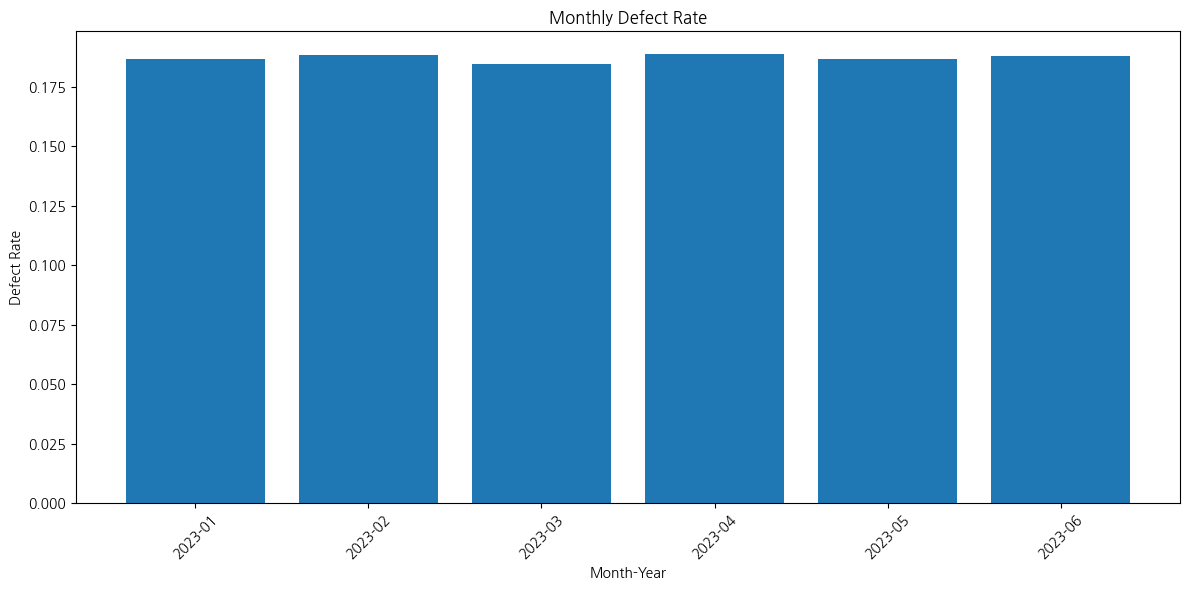

In [7]:
# Convert the 'Datetime' column to datetime format and extract the month-year for grouping
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%d-%m-%Y')
df['Month_Year'] = df['Datetime'].dt.to_period('M')

# Calculate the monthly defect rate
monthly_defect_rate = df.groupby('Month_Year').apply(lambda x: x['Target'].sum() / (520 * len(x)))

# Convert the result to a DataFrame for plotting
monthly_defect_rate = monthly_defect_rate.reset_index(name='Defect_Rate')

import matplotlib.pyplot as plt

# Plotting the monthly defect rate as a bar chart
plt.figure(figsize=(12, 6))
plt.bar(monthly_defect_rate['Month_Year'].astype(str), monthly_defect_rate['Defect_Rate'])
plt.xlabel('Month-Year')
plt.ylabel('Defect Rate')
plt.title('Monthly Defect Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

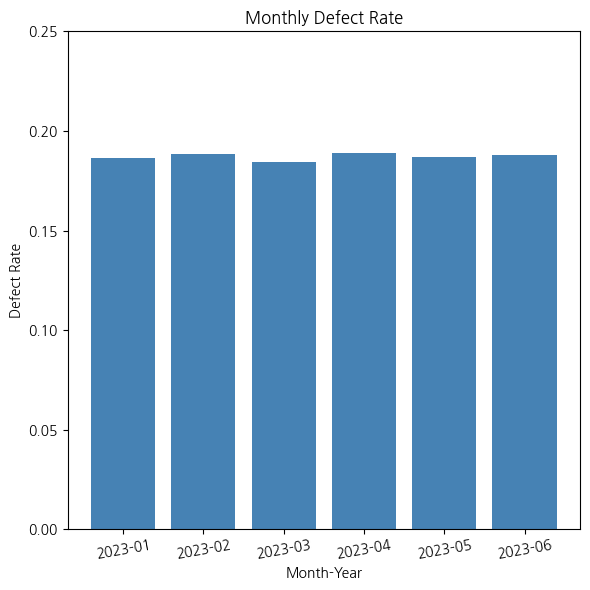

In [13]:
# Plotting the monthly defect rate again with an increased y-axis range to emphasize differences
plt.figure(figsize=(6, 6))
plt.bar(monthly_defect_rate['Month_Year'].astype(str), monthly_defect_rate['Defect_Rate'], color='steelblue')
plt.xlabel('Month-Year')
plt.ylabel('Defect Rate')
plt.title('Monthly Defect Rate')
plt.ylim(0, 0.25)  # Increase y-axis limit to emphasize differences
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

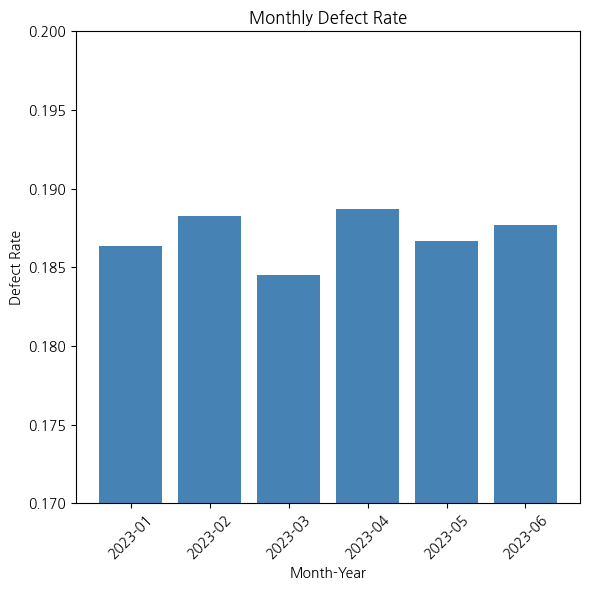

In [18]:
# Re-plotting the monthly defect rate with enhanced y-axis limits to make differences more noticeable
plt.figure(figsize=(6, 6))
plt.bar(monthly_defect_rate['Month_Year'].astype(str), monthly_defect_rate['Defect_Rate'], color='steelblue')
plt.xlabel('Month-Year')
plt.ylabel('Defect Rate')
plt.title('Monthly Defect Rate')
plt.ylim(0.17, 0.20)  # Narrowing y-axis range to emphasize small differences
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
monthly_defect_rate['Defect_Rate']

0    0.186379
1    0.188288
2    0.184523
3    0.188740
4    0.186669
5    0.187723
Name: Defect_Rate, dtype: float64

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# 데이터 로드
df = pd.read_csv('/home/piai/반도체 데이터 분석/Final2_data.csv')

# Datetime 열을 날짜 형식으로 변환하고 요일 추출
df['Datetime'] = pd.to_datetime(df['Datetime'], dayfirst=True, errors='coerce')
df['Day_of_Week'] = df['Datetime'].dt.day_name()

# 요일별 Target과 Target_error의 평균 차이 검정을 위한 ANOVA
# 요일별 그룹으로 나누기
target_by_day = [group['Target'].dropna() for name, group in df.groupby('Day_of_Week')]
target_error_by_day = [group['Target_error'].dropna() for name, group in df.groupby('Day_of_Week')]

# ANOVA 검정 수행
anova_target = f_oneway(*target_by_day)
anova_target_error = f_oneway(*target_error_by_day)

print("ANOVA Test for Target:", anova_target)
print("ANOVA Test for Target_error:", anova_target_error)

# 요일별 Target 및 Target_error 평균 계산
target_mean_by_day = df.groupby('Day_of_Week')['Target'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
target_error_mean_by_day = df.groupby('Day_of_Week')['Target_error'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])

# 시각화
plt.figure(figsize=(14, 6))

# Target의 요일별 평균 시각화
plt.subplot(1, 2, 1)
sns.barplot(x=target_mean_by_day.index, y=target_mean_by_day.values)
plt.title('Mean Target by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Mean Target')

# Target_error의 요일별 비율 시각화
plt.subplot(1, 2, 2)
target_error_rate_by_day = df.groupby('Day_of_Week')['Target_error'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
sns.barplot(x=target_error_rate_by_day.index, y=target_error_rate_by_day.values)
plt.title('Proportion of Target Error (1) by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Proportion of Target Error (1)')

plt.tight_layout()
plt.show()


In [ ]:
df['Day_of_Week'].unique()

In [ ]:
# 평일(월~금) 데이터만 선택
df_weekdays = df[df['Day_of_Week'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])]

# 개별 웨이퍼별 불량률 계산: 각 웨이퍼의 불량률 = Target / (520 * 웨이퍼 1개)
df_weekdays['불량률'] = df_weekdays['Target'] / 520

# 요일별 평균 불량률 계산
avg_defect_rate_by_day = df_weekdays.groupby('Day_of_Week')['불량률'].mean()

# 시각화
plt.figure(figsize=(10, 6))
avg_defect_rate_by_day.plot(kind='bar')
plt.title('Average Defect Rate by Day of the Week (Weekdays)')
plt.xlabel('Day of the Week')
plt.ylabel('Average Defect Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import f_oneway

# 요일별 개별 웨이퍼의 불량률 계산
df_weekdays['불량률'] = df_weekdays['Target'] / 520

# 요일별 불량률 리스트 생성 (월~금)
defect_rate_by_day = [group['불량률'].dropna() for name, group in df_weekdays.groupby('Day_of_Week')]

# ANOVA 검정 수행
anova_result = f_oneway(*defect_rate_by_day)
anova_result

In [ ]:
df_weekdays['Day_of_Week'].nunique()

In [ ]:
df_weekdays

In [ ]:
df_final2.columns

In [ ]:
unique_counts = df_final2.nunique()
# 결과 출력
print("열별 유니크 값 개수:\n", unique_counts)

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 사용할 설명 변수 목록 정의
features = ['Temp_OXid', 'ppm', 'Pressure', 'Oxid_time',
            'N2_HMDS', 'pressure_HMDS','temp_HMDS','temp_HMDS_bake', 'time_HMDS_bake', 
            'spin1', 'spin2','spin3','photoresist_bake','temp_softbake','time_softbake',
            'Wavelength', 'Resolution', 'Energy_Exposure', 
            'Source_Power', 'Selectivity','Temp_Etching',
            'Flux60s','Flux90s','Flux160s', 'Flux480s','input_Energy', 'Temp_implantation', 
            'Furance_Temp', 'RTA_Temp']

# 설명 변수(X)와 목표 변수(y) 분리
df_raw_x = df_final2[features]
df_raw_y = df_final2['Target_error']

# 데이터 분할
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, # 설명변수 데이터
                                                                df_raw_y, # 목표변수 데이터
                                                                test_size = 0.3, # test 데이터의 비율
                                                                random_state = 1234)  # random state

print("분할 전 설명변수 데이터 :", df_raw_x.shape)
print("분할 후 설명변수 데이터 :Train", df_train_x.shape, "  Test",df_test_x.shape)

# 학습 데이터의 Target_error에서 0과 1의 개수 확인
train_target_counts = df_train_y.value_counts()
test_target_counts = df_test_y.value_counts()
print("학습 데이터에서 Target_error 값의 분포:")
print(f"0의 개수: {train_target_counts.get(0)}")
print(f"1의 개수: {train_target_counts.get(1)}\n")

print("테스트 데이터에서 Target_error 값의 분포:")
print(f"0의 개수: {test_target_counts.get(0)}")
print(f"1의 개수: {test_target_counts.get(1)}\n")

In [ ]:
tree_uncust = DecisionTreeClassifier(random_state=1234 )
tree_uncust.fit(df_train_x, df_train_y)

# train 데이터 정확도
print("Accuracy on training set: {:.3f}".format(tree_uncust.score(df_train_x, df_train_y)))
# test 데이터 정확도
print("Accuracy on test set: {:.3f}".format(tree_uncust.score(df_test_x, df_test_y)))

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# max_depth: 최대 깊이 변경.
para_depth = [depth for depth in range(3, 20)]

for v_max_depth in para_depth:
    tree = DecisionTreeClassifier(max_depth = v_max_depth, random_state=1234)
    tree.fit(df_train_x, df_train_y)
    train_accuracy.append(tree.score(df_train_x, df_train_y))
    test_accuracy.append(tree.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_depth = pd.DataFrame()
df_accuracy_depth["Depth"] = para_depth
df_accuracy_depth["TrainAccuracy"] = train_accuracy
df_accuracy_depth["TestAccuracy"] = test_accuracy

In [ ]:
# 모델 정확도 그래프 확인
plt.plot(para_depth, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_depth, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.legend()

max_depth = 9

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# min_samples_split: 분할하기 위한 노드의 최소 샘플 수 
para_split = [n_split * 10 for n_split in range(8, 11)]

for v_min_samples_split in para_split:
    tree = DecisionTreeClassifier(min_samples_split = v_min_samples_split, max_depth=9, random_state=1234)
    tree.fit(df_train_x, df_train_y)
    train_accuracy.append(tree.score(df_train_x, df_train_y))
    test_accuracy.append(tree.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_split = pd.DataFrame()
df_accuracy_split["MinSamplesSplit"] = para_split
df_accuracy_split["TrainAccuracy"] = train_accuracy
df_accuracy_split["TestAccuracy"] = test_accuracy

In [ ]:
# 정확도를 그래프로 표현
plt.plot(para_split, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_split, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.legend()

min_samples_split = 90

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# min_samples_leaf: 잎사귀 노드 최소 자료 수. 
para_leaf = [n_leaf * 2 for n_leaf in range(5,10)]

for v_min_samples_leaf in para_leaf:
    tree = DecisionTreeClassifier(min_samples_leaf = v_min_samples_leaf, 
                                  min_samples_split=90,
                                  max_depth=9, random_state=1234)
    tree.fit(df_train_x, df_train_y)
    train_accuracy.append(tree.score(df_train_x, df_train_y))
    test_accuracy.append(tree.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_leaf = pd.DataFrame()
df_accuracy_leaf["MinSamplesLeaf"] = para_leaf
df_accuracy_leaf["TrainAccuracy"] = train_accuracy
df_accuracy_leaf["TestAccuracy"] = test_accuracy

In [ ]:
# 모델 정확도 그래프 확인
plt.plot(para_leaf, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_leaf, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.legend()

min_samples_leaf = 14

In [ ]:
tree_final = DecisionTreeClassifier(max_depth=9, min_samples_split=90, 
                                    min_samples_leaf=14, random_state=1234)
tree_final.fit(df_train_x, df_train_y)

In [ ]:
# 평가
y_pred = tree_final.predict(df_test_x)
print("Test Accuracy: {0:.3f}\n".format(tree_final.score(df_test_x, df_test_y)))
print("Test Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))

# 목표변수의 빈도 불균형 : f1 score로 모델 평가 
print(classification_report(df_test_y, y_pred, digits=3))

In [ ]:
estimator = DecisionTreeClassifier()
# 구하고자 하는 parameter와 범위
param_grid = {"max_depth": para_depth, 
              "min_samples_split": para_split,
              "min_samples_leaf": para_leaf}

# 정확도가 높은 최적 parameter 찾기
grid_dt = GridSearchCV(estimator, param_grid, scoring="accuracy", n_jobs = -1)
grid_dt.fit(df_train_x, df_train_y)

print("best estimator model: \n{}".format(grid_dt.best_estimator_))
print("\nbest parameter: \n{}".format(grid_dt.best_params_))
print("\nbest score: \n{}".format(grid_dt.best_score_.round(3)))

In [ ]:
tree_final = DecisionTreeClassifier(max_depth=18, min_samples_leaf=10, 
                                    min_samples_split=80, random_state = 1234)
tree_final.fit(df_train_x, df_train_y)

In [ ]:
# 평가
y_pred = tree_final.predict(df_test_x)
print("Test Accuracy: {0:.3f}\n".format(tree_final.score(df_test_x, df_test_y)))
print("Test Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))

# 목표변수의 빈도 불균형 : f1 score로 모델 평가 
print(classification_report(df_test_y, y_pred, digits=3))

In [ ]:
df_op = pd.read_csv('/home/piai/반도체 데이터 분석/최적운전조건.csv')

In [ ]:
df_op

In [ ]:
df_op_x = df_op[features]

predictions = tree_final.predict(df_op_x)
print("Predictions for 최적운전조건 dataset:\n", predictions)

In [ ]:
df_op['Predicted_Target_error'] = predictions

In [ ]:
# 전체 데이터 개수
total_count = df_op['Predicted_Target_error'].count()

# 값이 1인 데이터 개수
count_1 = df_op[df_op['Predicted_Target_error'] == 1].count()['Predicted_Target_error']

# 비율 계산
ratio = count_1 / total_count
print("Predicted_Target_error 값이 1인 비율:", ratio)

In [ ]:
count_1